# March 18 Periodicity Pregate - Gate Only

This is a lightweight variant of `march18_periodicity_pregate.ipynb` for testing only the CE-only pre-periodicity gate.

It does **not** run the expensive periodic branch (`python -m malca.events --baseline-func phase_template`) and does **not** run post-filter periodicity validation.


In [1]:
from pathlib import Path
import hashlib
import importlib
import json
import sys

import matplotlib.pyplot as plt
import pandas as pd

def find_repo_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / "pyproject.toml").exists():
            return candidate
    raise FileNotFoundError("Could not find repo root (missing pyproject.toml).")


REPO_ROOT = find_repo_root(Path.cwd().resolve())
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from malca.notebook_paths import infer_run_dir, localize_lightcurve_frame_paths, resolve_repo_path
from malca.config.config_pipeline import MAG_BINS as ALL_MAG_BINS, WORKERS as DEFAULT_WORKERS
import malca.periodicity_gate as malca_periodicity_gate
from malca.manifest import build_manifest

malca_periodicity_gate = importlib.reload(malca_periodicity_gate)
apply_pre_periodicity_gate = malca_periodicity_gate.apply_pre_periodicity_gate

%matplotlib inline
plt.rcParams["figure.figsize"] = (10, 6)

print(f"Repo root: {REPO_ROOT}")
print("Loaded local MALCA pregate implementation.")


/home/calder/miniforge3/envs/malca/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Repo root: /home/calder/code/malca
Loaded local MALCA pregate implementation.


In [2]:
# Point INPUT_TABLE at an existing manifest/tag parquet with dat_path,
# or leave it as None and build a flat-directory manifest from FLAT_LC_DIR.
INPUT_TABLE = None
RUN_NAME = "runs_march18_bundle_all"
RUN_DIR = REPO_ROOT / "output" / "runs" / RUN_NAME
FLAT_LC_DIR = RUN_DIR / "bundle_assets" / "lightcurves"
INDEX_FILE = None
MAG_BINS = list(ALL_MAG_BINS)
N_WORKERS = min(8, DEFAULT_WORKERS)

# Set to a small integer, e.g. 200, for a quick smoke test before running all rows.
MAX_CANDIDATES = None

INPUT_TABLE = resolve_repo_path(INPUT_TABLE, repo_root=REPO_ROOT)
FLAT_LC_DIR = resolve_repo_path(FLAT_LC_DIR, repo_root=REPO_ROOT)
INDEX_FILE = resolve_repo_path(INDEX_FILE, repo_root=REPO_ROOT)

OUTPUT_DIR = REPO_ROOT / "output" / "diagnostics" / "march18_periodicity_pregate_gate_only"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# The pregate is CE-only: period grid -> {P/2, P, 2P} -> folded scatter choice.
GATE_KWARGS = {
    "min_period": 0.2,
    "max_period": 100.0,
    "n_periods": 5000,
    "ce_snr_threshold": 10.0,
    "min_points": 50,
    "scatter_ratio_max": 0.9,
    "workers": N_WORKERS,
}

GATE_LOGIC_TAG = "ce_only_folded_scatter_v2_gate_only"
GATE_RUN_TAG = hashlib.md5(
    json.dumps(
        {"logic_tag": GATE_LOGIC_TAG, "max_candidates": MAX_CANDIDATES, **GATE_KWARGS},
        sort_keys=True,
    ).encode("utf-8")
).hexdigest()[:10]

print(f"Using gate run tag: {GATE_RUN_TAG}")
print(f"Output dir: {OUTPUT_DIR}")


Using gate run tag: 5709196146
Output dir: /home/calder/code/malca/output/diagnostics/march18_periodicity_pregate_gate_only


In [3]:
if INPUT_TABLE is not None:
    input_path = Path(INPUT_TABLE)
    if input_path.suffix.lower() in {".parquet", ".pq"}:
        df_input = pd.read_parquet(input_path)
    else:
        df_input = pd.read_csv(input_path)

    input_run_dir = infer_run_dir(input_path) or infer_run_dir(RUN_DIR)
    df_input, localized_counts = localize_lightcurve_frame_paths(
        df_input,
        run_dir=input_run_dir,
        repo_root=REPO_ROOT,
        path_columns=("dat_path", "path", "lc_path"),
    )
    if localized_counts:
        print(f"Localized stored light-curve paths: {localized_counts}")

    input_path_col = "dat_path" if "dat_path" in df_input.columns else ("path" if "path" in df_input.columns else None)
    if input_path_col is None:
        raise KeyError("Input table must include a dat_path or path column.")

    exists_mask = df_input[input_path_col].map(lambda x: Path(str(x)).expanduser().exists() if pd.notna(x) else False)
    if not bool(exists_mask.all()):
        print(f"Retained {int(exists_mask.sum()):,} rows with local light curves.")
    df_input = df_input[exists_mask].reset_index(drop=True)
else:
    df_input = build_manifest(
        None,
        None,
        mag_bins=MAG_BINS,
        id_column="asas_sn_id",
        flat_lc_dir=FLAT_LC_DIR,
        index_file=INDEX_FILE,
        show_progress=True,
        n_workers=N_WORKERS,
    )
    df_input = df_input[df_input["dat_exists"]].reset_index(drop=True)

if MAX_CANDIDATES is not None:
    df_input = df_input.head(int(MAX_CANDIDATES)).reset_index(drop=True)
    print(f"Limited to first {len(df_input):,} candidates for smoke testing.")

print(f"Loaded {len(df_input):,} candidates")
display(df_input.head())


flat light curves: 100%|██████████| 9569/9569 [00:00<00:00, 368721.13it/s]

[warn] 9569 flat light curves lacked mag_bin metadata; downstream mag-bin filters will treat them as unparsed.
Loaded 9,569 candidates


,source_id,mag_bin,index_num,index_csv,lc_dir,lc_dir_exists,dat_path,dat_exists
0,103079222309,None,None,None,/home/calder/code/malca/output/runs/runs_march...,True,/home/calder/code/malca/output/runs/runs_march...,True
1,103079223768,None,None,None,/home/calder/code/malca/output/runs/runs_march...,True,/home/calder/code/malca/output/runs/runs_march...,True
2,103079224553,None,None,None,/home/calder/code/malca/output/runs/runs_march...,True,/home/calder/code/malca/output/runs/runs_march...,True
3,103079238346,None,None,None,/home/calder/code/malca/output/runs/runs_march...,True,/home/calder/code/malca/output/runs/runs_march...,True
4,103079246967,None,None,None,/home/calder/code/malca/output/runs/runs_march...,True,/home/calder/code/malca/output/runs/runs_march...,True


In [4]:
path_col = "dat_path" if "dat_path" in df_input.columns else "path"
checkpoint_path = OUTPUT_DIR / f"march18_periodicity_gate_only_checkpoint_{GATE_RUN_TAG}.parquet"
output_file = OUTPUT_DIR / f"march18_periodicity_gate_only_{GATE_RUN_TAG}.parquet"

df_gate = apply_pre_periodicity_gate(
    df_input,
    path_col=path_col,
    checkpoint_path=checkpoint_path,
    show_tqdm=True,
    **GATE_KWARGS,
)
df_gate.to_parquet(output_file, index=False)
print(f"Saved gate output to {output_file}")
print(f"Checkpoint: {checkpoint_path}")

label_counts = df_gate["pre_periodicity_label"].value_counts(dropna=False).rename_axis("label").to_frame("n")
display(label_counts)

summary_cols = [
    "pre_periodicity_score",
    "pre_periodicity_scatter_ratio",
    "pre_ce_snr",
    "pre_ce_entropy",
]
summary_cols = [col for col in summary_cols if col in df_gate.columns]
display(df_gate.groupby("pre_periodicity_label")[summary_cols].median(numeric_only=True))


[pre_periodicity_gate] 0 cached, processing 9569 light curves


Pre-periodicity gate: 100%|██████████| 9569/9569 [10:50<00:00, 14.70it/s]


Saved gate output to /home/calder/code/malca/output/diagnostics/march18_periodicity_pregate_gate_only/march18_periodicity_gate_only_5709196146.parquet
Checkpoint: /home/calder/code/malca/output/diagnostics/march18_periodicity_pregate_gate_only/march18_periodicity_gate_only_checkpoint_5709196146.parquet


,n
label,
non_periodic,5649
periodic,3920


,pre_periodicity_score,pre_periodicity_scatter_ratio,pre_ce_snr,pre_ce_entropy
pre_periodicity_label,,,,
non_periodic,6.901494,0.821728,6.901494,1.143061
periodic,14.879590,0.727037,14.879590,1.066882


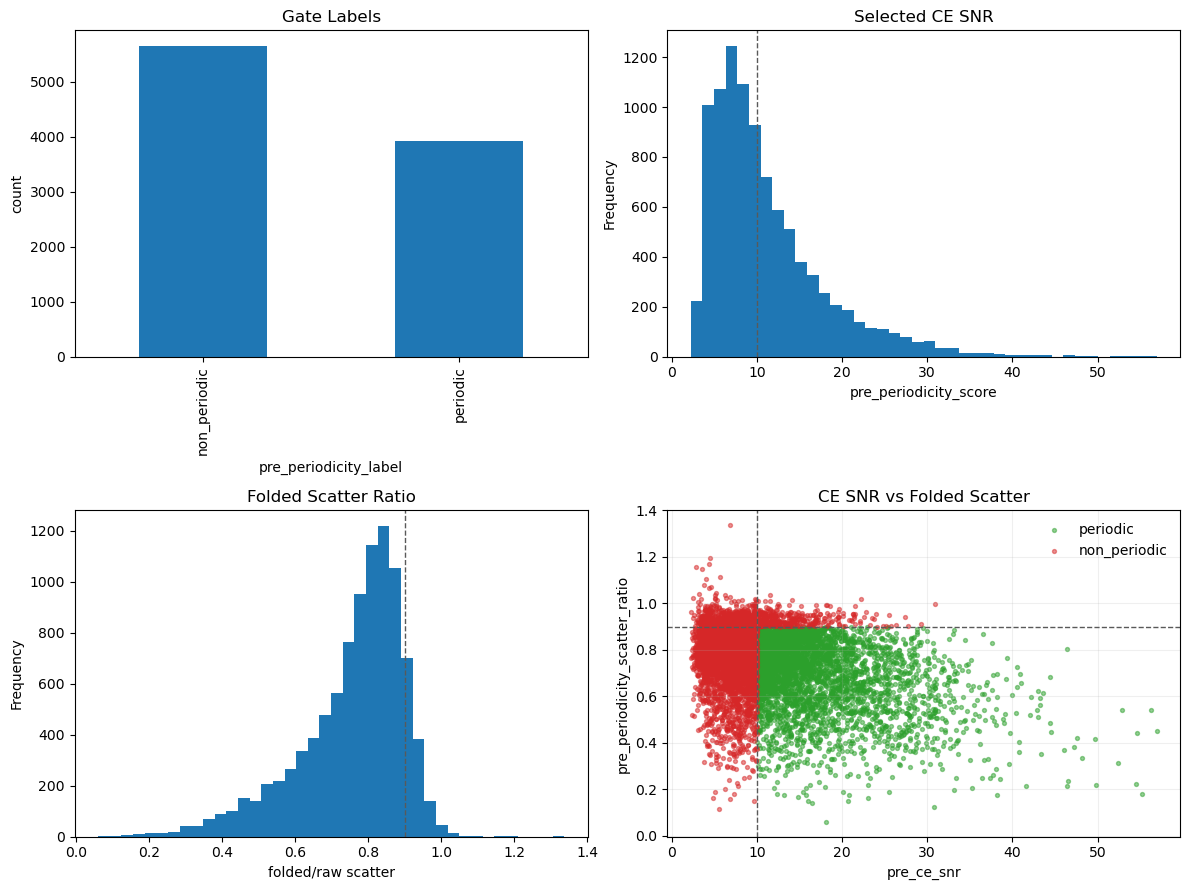

In [5]:
if df_gate.empty:
    print("No gate rows available for diagnostics.")
else:
    fig, axes = plt.subplots(2, 2, figsize=(12, 9))
    label_colors = {
        "periodic": "tab:green",
        "non_periodic": "tab:red",
    }

    threshold_ce_snr = float(GATE_KWARGS["ce_snr_threshold"])
    threshold_scatter = float(GATE_KWARGS["scatter_ratio_max"])

    df_gate["pre_periodicity_label"].value_counts().plot.bar(ax=axes[0, 0], title="Gate Labels")
    axes[0, 0].set_ylabel("count")

    df_gate["pre_periodicity_score"].dropna().plot.hist(ax=axes[0, 1], bins=40, title="Selected CE SNR")
    axes[0, 1].set_xlabel("pre_periodicity_score")
    axes[0, 1].axvline(threshold_ce_snr, color="0.35", ls="--", lw=1)

    df_gate["pre_periodicity_scatter_ratio"].dropna().plot.hist(ax=axes[1, 0], bins=40, title="Folded Scatter Ratio")
    axes[1, 0].set_xlabel("folded/raw scatter")
    axes[1, 0].axvline(threshold_scatter, color="0.35", ls="--", lw=1)

    for label, color in label_colors.items():
        subset = df_gate[df_gate["pre_periodicity_label"] == label]
        if subset.empty:
            continue
        axes[1, 1].scatter(
            subset["pre_ce_snr"],
            subset["pre_periodicity_scatter_ratio"],
            s=8,
            alpha=0.5,
            color=color,
            label=label,
        )
    axes[1, 1].axvline(threshold_ce_snr, color="0.35", ls="--", lw=1)
    axes[1, 1].axhline(threshold_scatter, color="0.35", ls="--", lw=1)
    axes[1, 1].set_title("CE SNR vs Folded Scatter")
    axes[1, 1].set_xlabel("pre_ce_snr")
    axes[1, 1].set_ylabel("pre_periodicity_scatter_ratio")
    axes[1, 1].legend(frameon=False)
    axes[1, 1].grid(alpha=0.2)

    plt.tight_layout()
    plt.show()


In [6]:
cols = [
    "source_id",
    "mag_bin",
    "pre_periodicity_label",
    "pre_periodicity_method",
    "pre_periodicity_base_period",
    "pre_periodicity_selected_period",
    "pre_periodicity_harmonic_factor",
    "pre_periodicity_score",
    "pre_periodicity_scatter_ratio",
    "pre_periodicity_support_count",
    "pre_ce_snr",
    "pre_ce_entropy",
    "pre_periodicity_reason",
]
cols = [col for col in cols if col in df_gate.columns]

print("Top confident periodic candidates")
display(df_gate[df_gate["pre_periodic_flag"]].sort_values("pre_periodicity_score", ascending=False)[cols].head(50))

print("Top non-periodic near-misses")
display(
    df_gate[~df_gate["pre_periodic_flag"]]
    .sort_values(["pre_periodicity_score", "pre_periodicity_scatter_ratio"], ascending=[False, True], na_position="last")[cols]
    .head(50)
)


Top confident periodic candidates


,source_id,mag_bin,pre_periodicity_label,pre_periodicity_method,pre_periodicity_base_period,pre_periodicity_selected_period,pre_periodicity_harmonic_factor,pre_periodicity_score,pre_periodicity_scatter_ratio,pre_periodicity_support_count,pre_ce_snr,pre_ce_entropy,pre_periodicity_reason
1690,197569701759,None,periodic,ce,0.898740,0.898740,1.0,56.946657,0.449104,1,56.946657,0.635197,"ce,folded_scatter"
4591,395137799832,None,periodic,ce,0.619244,0.619244,1.0,56.312381,0.542519,1,56.312381,0.998935,"ce,folded_scatter"
355,120259593915,None,periodic,ce,2.356111,1.178056,0.5,55.187352,0.180646,1,55.187352,1.771084,"ce,folded_scatter"
7237,575525802302,None,periodic,ce,1.078416,1.078416,1.0,54.668148,0.442943,1,54.668148,1.264382,"ce,folded_scatter,alias"
349,120259520345,None,periodic,ce,0.778956,0.778956,1.0,54.510673,0.224638,1,54.510673,0.800952,"ce,folded_scatter"
7248,575525842116,None,periodic,ce,0.798800,0.798800,1.0,52.907557,0.541001,1,52.907557,1.154181,"ce,folded_scatter"
3951,352187693563,None,periodic,ce,2.060484,2.060484,1.0,52.379238,0.311733,1,52.379238,1.193036,"ce,folded_scatter"
2071,223339617100,None,periodic,ce,2.416063,1.208032,0.5,49.868649,0.219911,1,49.868649,1.142152,"ce,folded_scatter"
4931,420907553024,None,periodic,ce,1.477696,1.477696,1.0,49.707862,0.418266,1,49.707862,0.319093,"ce,folded_scatter"
8113,618476236812,None,periodic,ce,2.416003,1.208002,0.5,48.145323,0.336735,1,48.145323,1.059027,"ce,folded_scatter"


Top non-periodic near-misses


,source_id,mag_bin,pre_periodicity_label,pre_periodicity_method,pre_periodicity_base_period,pre_periodicity_selected_period,pre_periodicity_harmonic_factor,pre_periodicity_score,pre_periodicity_scatter_ratio,pre_periodicity_support_count,pre_ce_snr,pre_ce_entropy,pre_periodicity_reason
8293,635655278147,None,non_periodic,ce,5.974485,11.948970,2.0,30.893024,0.995236,1,30.893024,0.495405,"ce,scatter_too_high"
6915,549756690257,None,non_periodic,ce,2.136507,2.136507,1.0,29.325453,0.913356,1,29.325453,0.852832,"ce,scatter_too_high"
7219,575525677849,None,non_periodic,ce,4.006634,4.006634,1.0,27.731916,0.902830,1,27.731916,1.001776,"ce,scatter_too_high"
4881,420907173853,None,non_periodic,ce,4.512282,4.512282,1.0,27.363841,0.940961,1,27.363841,0.650979,"ce,scatter_too_high"
2735,266288971501,None,non_periodic,ce,7.346930,3.673465,0.5,26.273403,0.906353,1,26.273403,0.890796,"ce,scatter_too_high"
4610,395138044117,None,non_periodic,ce,3.355030,3.355030,1.0,25.776224,0.902360,1,25.776224,0.912720,"ce,scatter_too_high"
2883,283468048045,None,non_periodic,ce,7.047709,7.047709,1.0,25.475152,0.950337,1,25.475152,1.099919,"ce,scatter_too_high"
5791,481036595213,None,non_periodic,ce,10.042248,10.042248,1.0,25.108654,0.902468,1,25.108654,0.664856,"ce,scatter_too_high"
6010,498216321943,None,non_periodic,ce,8.971080,4.485540,0.5,24.826959,0.900884,1,24.826959,0.922221,"ce,scatter_too_high"
8612,652835102822,None,non_periodic,ce,5.889558,2.944779,0.5,24.103391,0.900417,1,24.103391,1.100521,"ce,scatter_too_high"


In [ ]:
# Select representative cases for raw + phase-folded gate plots.
# This stays gate-only: it reads light curves and plots the pregate-selected period,
# but it does not run events.py or apply_filters.
import numpy as np

PLOT_ROWS_PER_LABEL = 4
GATE_PLOT_PATH_COL = "dat_path" if "dat_path" in df_gate.columns else "path"
GATE_PLOT_ID_COL = next((col for col in ["source_id", "asas_sn_id", "name"] if col in df_gate.columns), None)


def _plot_num(df, col, default=np.nan):
    if col not in df.columns:
        return pd.Series(default, index=df.index, dtype=float)
    return pd.to_numeric(df[col], errors="coerce")


def add_gate_plot_metrics(df):
    out = df.copy()
    ce_snr_thr = float(GATE_KWARGS.get("ce_snr_threshold", 10.0))
    scatter_thr = float(GATE_KWARGS.get("scatter_ratio_max", 0.9))

    ce_snr = _plot_num(out, "pre_ce_snr")
    scatter = _plot_num(out, "pre_periodicity_scatter_ratio")
    support_count = _plot_num(out, "pre_periodicity_support_count", default=0.0).fillna(0.0)
    alias_flag = out.get("pre_periodicity_alias_flag", pd.Series(False, index=out.index)).fillna(False).astype(bool)

    ce_def = pd.Series(
        np.where(np.isfinite(ce_snr) & (ce_snr > 0), np.maximum((ce_snr_thr / ce_snr) - 1.0, 0.0), 1.0),
        index=out.index,
    )
    scatter_def = pd.Series(
        np.where(np.isfinite(scatter), np.maximum((scatter / scatter_thr) - 1.0, 0.0), 1.0),
        index=out.index,
    )
    support_def = pd.Series(np.maximum(1.0 - support_count, 0.0), index=out.index)

    ce_strength = pd.Series(
        np.where(np.isfinite(ce_snr), np.clip(ce_snr / ce_snr_thr, 0.0, 5.0), 0.0),
        index=out.index,
    )
    scatter_strength = pd.Series(
        np.where(np.isfinite(scatter) & (scatter > 0), np.clip(scatter_thr / scatter, 0.0, 5.0), 0.0),
        index=out.index,
    )

    out["pre_periodicity_plot_distance"] = ce_def + scatter_def + support_def + (0.25 * alias_flag.astype(float))
    out["pre_periodicity_plot_strength"] = support_count + ce_strength + (0.5 * scatter_strength) - (0.5 * alias_flag.astype(float))
    return out


df_gate_plot = add_gate_plot_metrics(df_gate)
plot_case_frames = []

periodic_cases = (
    df_gate_plot[df_gate_plot["pre_periodicity_label"] == "periodic"]
    .sort_values(["pre_periodicity_plot_strength", "pre_periodicity_score"], ascending=[False, False], na_position="last")
    .head(PLOT_ROWS_PER_LABEL)
    .copy()
)
if not periodic_cases.empty:
    periodic_cases["plot_case"] = "strong periodic"
    plot_case_frames.append(periodic_cases)

near_miss_cases = (
    df_gate_plot[df_gate_plot["pre_periodicity_label"] == "non_periodic"]
    .sort_values(["pre_periodicity_plot_distance", "pre_periodicity_plot_strength"], ascending=[True, False], na_position="last")
    .head(PLOT_ROWS_PER_LABEL)
    .copy()
)
if not near_miss_cases.empty:
    near_miss_cases["plot_case"] = "closest non-periodic near miss"
    plot_case_frames.append(near_miss_cases)

gate_plot_cases = pd.concat(plot_case_frames, ignore_index=True) if plot_case_frames else pd.DataFrame()

plot_display_cols = [
    "plot_case",
    GATE_PLOT_ID_COL,
    "mag_bin",
    "pre_periodicity_label",
    "pre_periodicity_plot_distance",
    "pre_periodicity_plot_strength",
    "pre_periodicity_selected_period",
    "pre_periodicity_harmonic_factor",
    "pre_periodicity_score",
    "pre_periodicity_scatter_ratio",
    "pre_ce_snr",
    "pre_periodicity_reason",
]
plot_display_cols = [col for col in plot_display_cols if col and col in gate_plot_cases.columns]

print(f"Selected {len(gate_plot_cases)} gate cases for raw and phase-folded plots.")
if not gate_plot_cases.empty:
    display(gate_plot_cases[plot_display_cols])


In [ ]:
# Plot raw and phase-folded views for selected pregate cases.
BAND_COLORS = {0: "tab:green", 1: "tab:blue"}
BAND_LABELS = {0: "g band", 1: "V band"}

load_lightcurve_df = malca_periodicity_gate.load_lightcurve_df
clean_lc = malca_periodicity_gate.clean_lc
apply_simple_band_median_offset = malca_periodicity_gate.apply_simple_band_median_offset
BAD_CAMERA_SCATTER_RATIO_THRESHOLD = malca_periodicity_gate.BAD_CAMERA_SCATTER_RATIO_THRESHOLD
CLEAN_LC_MAX_ERROR_ABSOLUTE = malca_periodicity_gate.CLEAN_LC_MAX_ERROR_ABSOLUTE
CLEAN_LC_MAX_ERROR_SIGMA = malca_periodicity_gate.CLEAN_LC_MAX_ERROR_SIGMA


def _excluded_camera_set(value):
    if isinstance(value, str):
        return {int(item.strip()) for item in value.split(",") if item.strip()}
    if isinstance(value, (set, list, tuple)):
        return {int(item) for item in value}
    return set()


def _coerce_scalar(value):
    return pd.to_numeric(pd.Series([value]), errors="coerce").iloc[0]


def _format_scalar(value, fmt):
    scalar = _coerce_scalar(value)
    return format(float(scalar), fmt) if pd.notna(scalar) else "nan"


def _load_gate_lightcurve(row):
    df_lc = load_lightcurve_df(
        row[GATE_PLOT_PATH_COL],
        filter_bad_cameras_enabled=True,
        bad_camera_scatter_ratio=BAD_CAMERA_SCATTER_RATIO_THRESHOLD,
    )
    excluded = _excluded_camera_set(row.get("excluded_cameras"))
    if excluded and "camera#" in df_lc.columns:
        df_lc = df_lc[~df_lc["camera#"].isin(excluded)].reset_index(drop=True)
    df_lc = clean_lc(
        df_lc,
        max_error_absolute=CLEAN_LC_MAX_ERROR_ABSOLUTE,
        max_error_sigma=CLEAN_LC_MAX_ERROR_SIGMA,
    )
    return df_lc.reset_index(drop=True)


def _scatter_by_band(ax, df_lc, x, *, xlabel, ylabel=None):
    if "v_g_band" in df_lc.columns:
        for band, band_df in df_lc.groupby("v_g_band"):
            band_int = int(band)
            ax.scatter(
                band_df[x],
                band_df["mag"],
                s=10,
                alpha=0.65,
                color=BAND_COLORS.get(band_int, "tab:gray"),
                label=BAND_LABELS.get(band_int, f"band {band_int}"),
            )
    else:
        ax.scatter(df_lc[x], df_lc["mag"], s=10, alpha=0.65, color="tab:gray")
    ax.set_xlabel(xlabel)
    if ylabel:
        ax.set_ylabel(ylabel)
    ax.invert_yaxis()
    ax.grid(alpha=0.2)


def _plot_gate_case(ax_raw, ax_phase, row):
    df_lc = _load_gate_lightcurve(row)
    candidate_id = row.get(GATE_PLOT_ID_COL, row.name) if GATE_PLOT_ID_COL else row.name
    period = _coerce_scalar(row.get("pre_periodicity_selected_period"))
    base_period = _coerce_scalar(row.get("pre_periodicity_base_period"))
    harmonic_factor = _coerce_scalar(row.get("pre_periodicity_harmonic_factor"))
    case_label = row.get("plot_case", "gate case")

    period_str = f"{period:.5g} d" if pd.notna(period) and period > 0 else "n/a"
    base_period_str = f"{base_period:.5g} d" if pd.notna(base_period) and base_period > 0 else "n/a"
    harmonic_factor_str = f"{harmonic_factor:.5g}" if pd.notna(harmonic_factor) and harmonic_factor > 0 else "n/a"
    edge_distance = _format_scalar(row.get("pre_periodicity_plot_distance"), ".3f")
    edge_strength = _format_scalar(row.get("pre_periodicity_plot_strength"), ".2f")
    scatter = _format_scalar(row.get("pre_periodicity_scatter_ratio"), ".2f")
    ce_snr = _format_scalar(row.get("pre_ce_snr"), ".1f")
    score = _format_scalar(row.get("pre_periodicity_score"), ".1f")

    header = f"{case_label} | candidate {candidate_id}"
    meta = (
        f"label={row.get('pre_periodicity_label', 'n/a')}  distance={edge_distance}  strength={edge_strength}\n"
        f"selected={period_str}  base={base_period_str}  factor={harmonic_factor_str}\n"
        f"score={score}  ce_snr={ce_snr}  scatter={scatter}\n"
        f"reason={row.get('pre_periodicity_reason', '')}"
    )
    ax_raw.set_title(header, loc="left", fontsize=11)

    if df_lc.empty:
        ax_raw.text(0.5, 0.5, "No clean light curve", ha="center", va="center")
        ax_phase.text(0.5, 0.5, "No clean light curve", ha="center", va="center")
        ax_raw.axis("off")
        ax_phase.axis("off")
        return

    df_plot, v_minus_g_offset = apply_simple_band_median_offset(df_lc)
    _scatter_by_band(ax_raw, df_plot, "JD", xlabel="JD", ylabel="mag (band-aligned)")
    ax_raw.text(
        0.01,
        0.02,
        meta + f"\nv_minus_g_offset={v_minus_g_offset:.3f}" if np.isfinite(v_minus_g_offset) else meta,
        transform=ax_raw.transAxes,
        fontsize=8,
        va="bottom",
        ha="left",
        bbox={"facecolor": "white", "alpha": 0.85, "edgecolor": "none"},
    )
    handles, labels = ax_raw.get_legend_handles_labels()
    if handles:
        ax_raw.legend(handles, labels, loc="upper right", fontsize=8)

    if not pd.notna(period) or period <= 0:
        ax_phase.text(0.5, 0.5, "No selected period", ha="center", va="center")
        ax_phase.set_axis_off()
        return

    phase = np.mod((df_plot["JD"] - df_plot["JD"].min()) / float(period), 1.0)
    phase_df = df_plot.assign(phase=phase)
    phase_wrap = pd.concat(
        [phase_df.assign(phase_plot=phase_df["phase"]), phase_df.assign(phase_plot=phase_df["phase"] + 1.0)],
        ignore_index=True,
    )
    _scatter_by_band(ax_phase, phase_wrap, "phase_plot", xlabel="phase")
    ax_phase.set_xlim(0.0, 2.0)
    ax_phase.axvline(1.0, color="0.5", ls="--", lw=1)
    ax_phase.set_title(f"Phase-folded | selected={period_str}", fontsize=10)


if gate_plot_cases.empty:
    print("No gate plot cases selected.")
else:
    fig, axes = plt.subplots(len(gate_plot_cases), 2, figsize=(14, 3.8 * len(gate_plot_cases)), constrained_layout=True)
    axes = np.atleast_2d(axes)
    for ax_pair, (_, row) in zip(axes, gate_plot_cases.iterrows()):
        _plot_gate_case(ax_pair[0], ax_pair[1], row)
    plt.show()
